In [1]:
print("project setup done")

project setup done


Superstore Sales Analysis Project

## 1. Introduction

This project analyzes the Superstore dataset to understand sales performance,
profitability trends, and the impact of discounting on business outcomes.

The objective is to identify revenue drivers, loss-making segments,
and provide data-driven business recommendations.

In [2]:
import os
print(os.getcwd())

c:\Users\ANKA SIDHU\Project_1_Sales_Analysis\Notebook


In [3]:
import pandas as pd

#df=pd.read_csv("../Data/Sample - Superstore.csv", encoding="latin1")
df=pd.read_csv("../Data/Sample - Superstore.csv",encoding="latin1")
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820


## 2. Dataset Overview

The dataset contains transactional sales data from 2015 to 2017,
including information about:

- Sales
- Profit
- Discount
- Category
- Sub-Category
- Order Date
- Region and State

We begin by understanding the structure and summary statistics of the dataset.

In [4]:
df.shape

(9994, 21)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [15]:
Total_sales=df['Sales'].sum()
#df['Profit'].sum()
print("total sales:",Total_sales)
 

total sales: 2297200.8603000003


In [16]:
Total_profit=df['Profit'].sum()
print("total profit:",Total_profit)

total profit: 286397.0217


In [17]:
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

In [20]:
df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64

In [21]:
#find top 5 States by sales
df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(5)

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Name: Sales, dtype: float64

In [23]:
#find top 5 Citys by profit
df.groupby("City")["Profit"].sum().sort_values(ascending=False).head(5)



City
New York City    62036.9837
Los Angeles      30440.7579
Seattle          29156.0967
San Francisco    17507.3854
Detroit          13181.7908
Name: Profit, dtype: float64

In [ ]:
#Monthly Sales Trand(very important)
df["Order Date"]=pd.to_datetime(df["Order Date"])  #first convert order data to datetime

## 3. Sales Analysis

Sales trends were analyzed on a monthly basis.

Key Findings:
- April 2017 recorded the highest sales.
- Sales show seasonal fluctuations across years.
- Revenue peaks are observed during certain promotional periods.

In [26]:
#now extract monthe
df["Month"]=df["Order Date"].dt.to_period("M")

In [34]:
#now group

Monthly_Sales=df.groupby("Month")["Sales"].sum()
Monthly_Sales.head()

Month
2014-01    14236.895
2014-02     4519.892
2014-03    55691.009
2014-04    28295.345
2014-05    23648.287
Freq: M, Name: Sales, dtype: float64

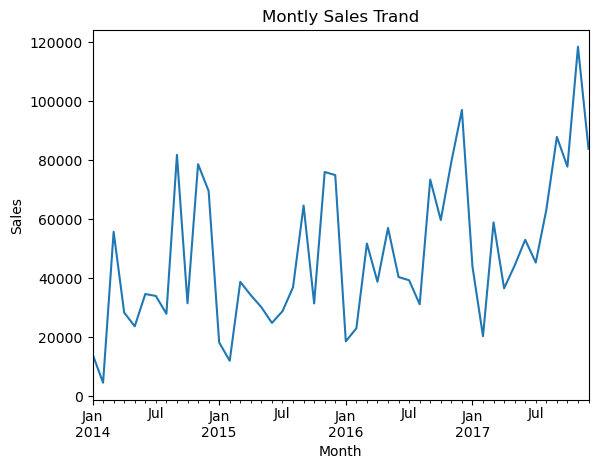

In [43]:
import matplotlib.pyplot as plt

Monthly_Sales.plot()
plt.title("Montly Sales Trand")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()


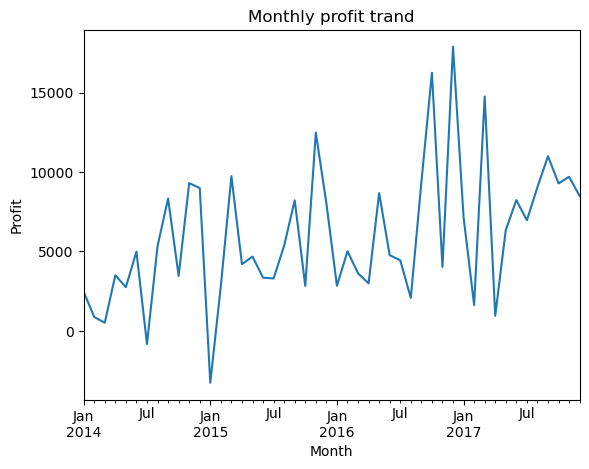

In [44]:
#Monthly profit trand
Monthly_profit=df.groupby("Month")["Profit"].sum()

Monthly_profit.plot()
plt.title("Monthly profit trand")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.show()

## 4. Profit Analysis

Profit trends were compared with sales trends to understand margin performance.

Key Findings:
- December 2016 recorded the highest profit.
- January 2015 recorded a negative profit despite reasonable sales.
- High sales months do not always result in high profitability.

In [45]:
Monthly_Sales.sort_values(ascending=False).head(5)

Month
2017-11    118447.8250
2016-12     96999.0430
2017-09     87866.6520
2017-12     83829.3188
2014-09     81777.3508
Freq: M, Name: Sales, dtype: float64

In [47]:
# for profit
Monthly_profit.sort_values().head(5)

Month
2015-01   -3281.0070
2014-07    -841.4826
2014-03     498.7299
2014-02     862.3084
2017-04     933.2900
Freq: M, Name: Profit, dtype: float64

In [48]:
#cheak Profit in that Month
Monthly_profit["2017-04 "]

933.2899999999998

In [49]:
#lets find top 5 monthes
Monthly_Sales.sort_values(ascending=False).head()

Month
2017-11    118447.8250
2016-12     96999.0430
2017-09     87866.6520
2017-12     83829.3188
2014-09     81777.3508
Freq: M, Name: Sales, dtype: float64

In [54]:
df[df["Month"]=="2017-04"].groupby("Category")["Sales"].sum()

Category
Furniture           9065.9581
Office Supplies    15072.1910
Technology         12383.3870
Name: Sales, dtype: float64

In [55]:
df[df["Month"]=="2017-04"]["Discount"].mean()

0.1944334975369458

## 5. Discount Impact Analysis

The relationship between discount and profit was examined.

Key Observations:
- April 2017 had high sales but also a high discount rate (19%),
  which reduced overall profit.
- January 2015 had a 17% average discount and resulted in negative profit.
- December 2016 had a lower discount (13%) and achieved the highest profit.

Conclusion:
Higher discount rates increased sales volume but reduced profitability.

In [58]:
df.groupby("Discount")["Profit"].mean().sort_values().head()

Discount
0.50   -310.703456
0.45   -226.646464
0.40   -111.927429
0.80   -101.796797
0.70    -95.874060
Name: Profit, dtype: float64

In [59]:
Monthly_profit["2017-04"]

933.2899999999998

In [60]:
Monthly_profit.sort_values(ascending=False).head()

Month
2016-12    17885.3093
2016-10    16243.1425
2017-03    14751.8915
2015-11    12474.7884
2017-09    10991.5556
Freq: M, Name: Profit, dtype: float64

In [ ]:
#December disscount
df[df["Month"]=="2016-12 "]["Discount"].mean()

0.13542613636363637

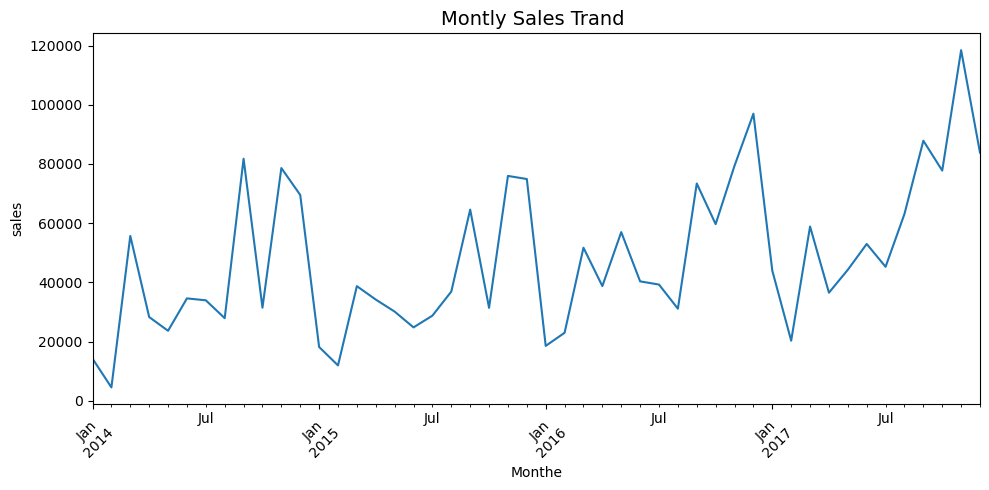

In [62]:
#Create Clean Visual Dashabord Style Plots

plt.figure(figsize=(10,5))

Monthly_Sales.plot()

plt.title("Montly Sales Trand ",fontsize=14)
plt.xlabel("Monthe")
plt.ylabel("sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

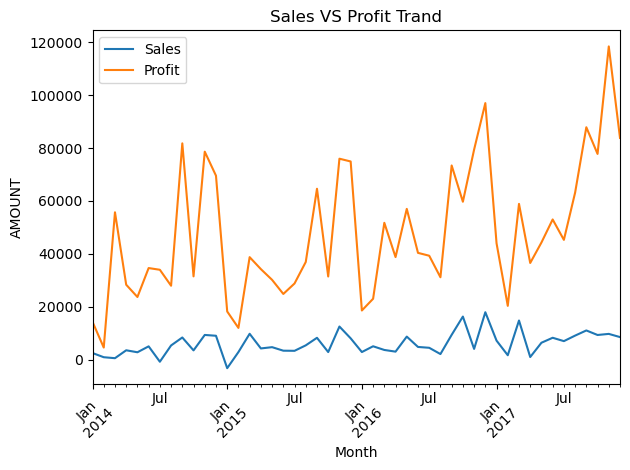

In [63]:
#Compare Sales VS Profit Togther
plt.Figure(figsize=(14,5))

Monthly_profit.plot(label="Sales")
Monthly_Sales.plot(label="Profit")
plt.title("Sales VS Profit Trand")
plt.xlabel("Month")
plt.ylabel("AMOUNT")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

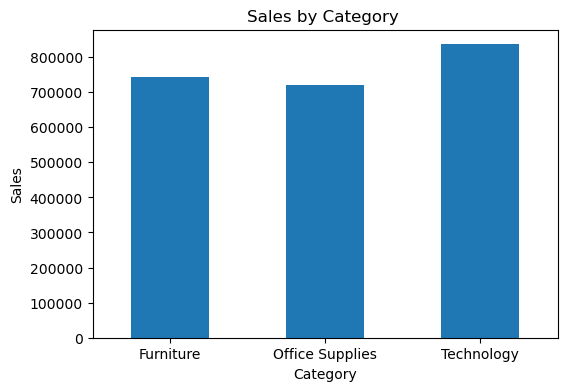

In [72]:
category_sales=df.groupby("Category")["Sales"].sum()

#Sub_category_sales=df.groupby("Sub-Category")["Sales"].sum()

plt.figure(figsize=(6,4))
category_sales.plot(kind="bar")
#Sub_category_sales.plot(kind="bar")
#plt.title("Sales by Category and Sub-Category")
plt.title("Sales by Category ")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.show()

In [74]:
Monthly_profit["2015-01"]


-3281.007

In [75]:
Monthly_Sales["2015-01"]

18174.0756

In [78]:
df[df["Month"]=="2015-01"]["Discount"].mean()

0.1779310344827586

In [79]:
df.groupby("Category")["Profit"].sum().sort_values()

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

In [80]:
df.groupby("Sub-Category")["Profit"].sum().sort_values()

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64

In [82]:
df[df["Category"]=="Furniture"].groupby("Sub-Category")["Profit"].sum().sort_values()

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Furnishings    13059.1436
Chairs         26590.1663
Name: Profit, dtype: float64

## 6. Root Cause Analysis – Furniture Category

The Furniture category showed significantly lower profitability compared
to Technology and Office Supplies.

Further breakdown revealed:

- Tables sub-category generated a major loss (-17,725).
- Tables had an average discount of 26%.
- Overall average discount across dataset was 15%.

This indicates excessive discounting in Tables caused margin erosion.

In [83]:
df[df["Sub-Category"]=="Tables"]["Discount"].mean()

0.26128526645768024

In [84]:
df["Discount"].mean()

0.15620272163297977

In [86]:
tables_data = df[df["Sub-Category"] == "Tables"]

tables_data.groupby("Discount")["Profit"].mean().sort_values().head() 

Discount
0.50   -239.316314
0.45   -226.646464
0.40   -215.831957
0.30    -63.006067
0.20     -4.275465
Name: Profit, dtype: float64

In [87]:
print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())
print("Average Discount:", df["Discount"].mean())

Total Sales: 2297200.8603000003
Total Profit: 286397.0217
Average Discount: 0.15620272163297977


In [88]:
# Highest Profit Category
print(df.groupby("Category")["Profit"].sum().sort_values(ascending=False))

# Worst Sub-Category
print(df.groupby("Sub-Category")["Profit"].sum().sort_values().head())

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64
Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Fasteners      949.5182
Machines      3384.7569
Name: Profit, dtype: float64


In [89]:
df[["Sales","Profit","Discount"]].corr()

,Sales,Profit,Discount
Sales,1.000000,0.479064,-0.028190
Profit,0.479064,1.000000,-0.219487
Discount,-0.028190,-0.219487,1.000000


## 7. Business Recommendations

Based on the analysis:

1. Reduce excessive discounting in the Tables sub-category.
2. Monitor profit margins during promotional campaigns.
3. Focus on Technology category for high-margin growth.
4. Implement smarter discount strategies to balance sales and profitability.

This analysis highlights the importance of pricing strategy
in maintaining sustainable business growth.